<a href="https://colab.research.google.com/github/Varshith-CS/CSCI-164/blob/main/ML%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Healthcare Data Analysis: Supervised Machine Learning Project**

This notebook covers a complete machine learning workflow applied to three healthcare datasets: the Pima Indians Diabetes dataset, the Cleveland Heart Disease dataset, and the Medical Insurance Costs dataset. For each dataset I explore the data, preprocess it, train two to three supervised learning models, tune hyperparameters using GridSearchCV, evaluate performance using appropriate metrics, and compare results to prior published work. The goal is to demonstrate the full pipeline from raw data to trained and evaluated models using scikit-learn.

Datasets used:
1. Pima Indians Diabetes,
2. Cleveland Heart Disease,
3. Medical Insurance Costs


Algorithms used:
1. Logistic Regression,
2. Random Forest, MLP (Datasets 1 and 2),
3. Linear Regression, Decision Tree,
4. Random Forest Regressor (Dataset 3)


Author: Varshith Nakkina


Section 1 — Setup and Imports

This section loads all the libraries needed for the rest of the notebook including scikit-learn for modeling, pandas and numpy for data handling, and matplotlib and seaborn for visualization.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# Sklearn — classifiers
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
PALETTE = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
print("✅ All imports successful")
print(f"   scikit-learn version: {__import__('sklearn').__version__}")
print(f"   pandas version: {pd.__version__}")
print(f"   numpy version: {np.__version__}")


✅ All imports successful
   scikit-learn version: 1.6.1
   pandas version: 2.2.2
   numpy version: 2.0.2


Section 2 — Dataset 1: Pima Indians Diabetes

2.1 Overview and Motivation

The Pima Indians Diabetes Database comes from the National Institute of Diabetes and Digestive and Kidney Diseases. It has 768 records from adult Pima Indian women aged 21 and older, and the goal is to predict whether a patient has diabetes based on eight diagnostic measurements.

I chose this dataset because it is one of the most widely studied datasets in medical machine learning, which makes it easy to compare my results to published benchmarks. The features are all biologically meaningful — things like glucose level, BMI, insulin, and blood pressure. One important challenge with this dataset is that some features contain zeros that are not actually zero, they represent missing measurements. I deal with that in the preprocessing step below.

The target variable is called Outcome, where 1 means diabetic and 0 means not diabetic.


In [69]:
# ── Load ──────────────────────────────────────────────────────
df_diab = pd.read_csv('diabetes.csv')
print("Shape:", df_diab.shape)
print("\nFirst 5 rows:")
df_diab.head()


Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [70]:
# ── Basic statistics ──────────────────────────────────────────
print("=== Descriptive Statistics ===")
df_diab.describe().round(2)


=== Descriptive Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


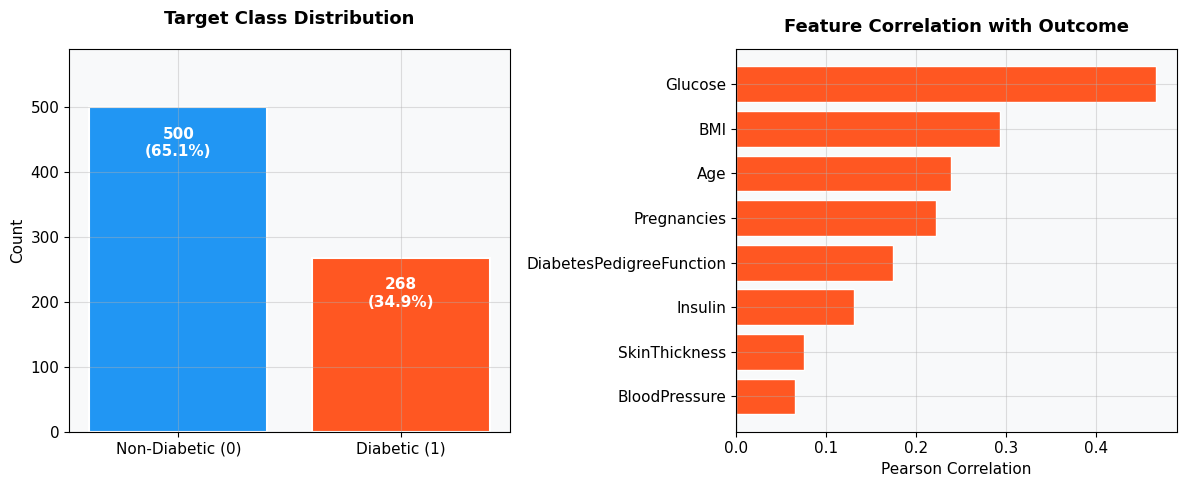

Figure saved.


In [71]:
# ── Class distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class balance
counts = df_diab['Outcome'].value_counts()
bars = axes[0].bar(['Non-Diabetic (0)', 'Diabetic (1)'], counts.values,
            color=['#2196F3', '#FF5722'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', pad=18)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.values.max() * 1.18)
for bar, v in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 30,
        f'{v}\n({v/len(df_diab)*100:.1f}%)',
        ha='center', va='top', fontweight='bold', color='white', fontsize=11
    )

# Feature correlations with outcome
corr = df_diab.corr()['Outcome'].drop('Outcome').sort_values(ascending=True)
colors = ['#FF5722' if x > 0 else '#2196F3' for x in corr.values]
axes[1].barh(corr.index, corr.values, color=colors, edgecolor='white')
axes[1].set_title('Feature Correlation with Outcome', pad=12)
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('diab_eda1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


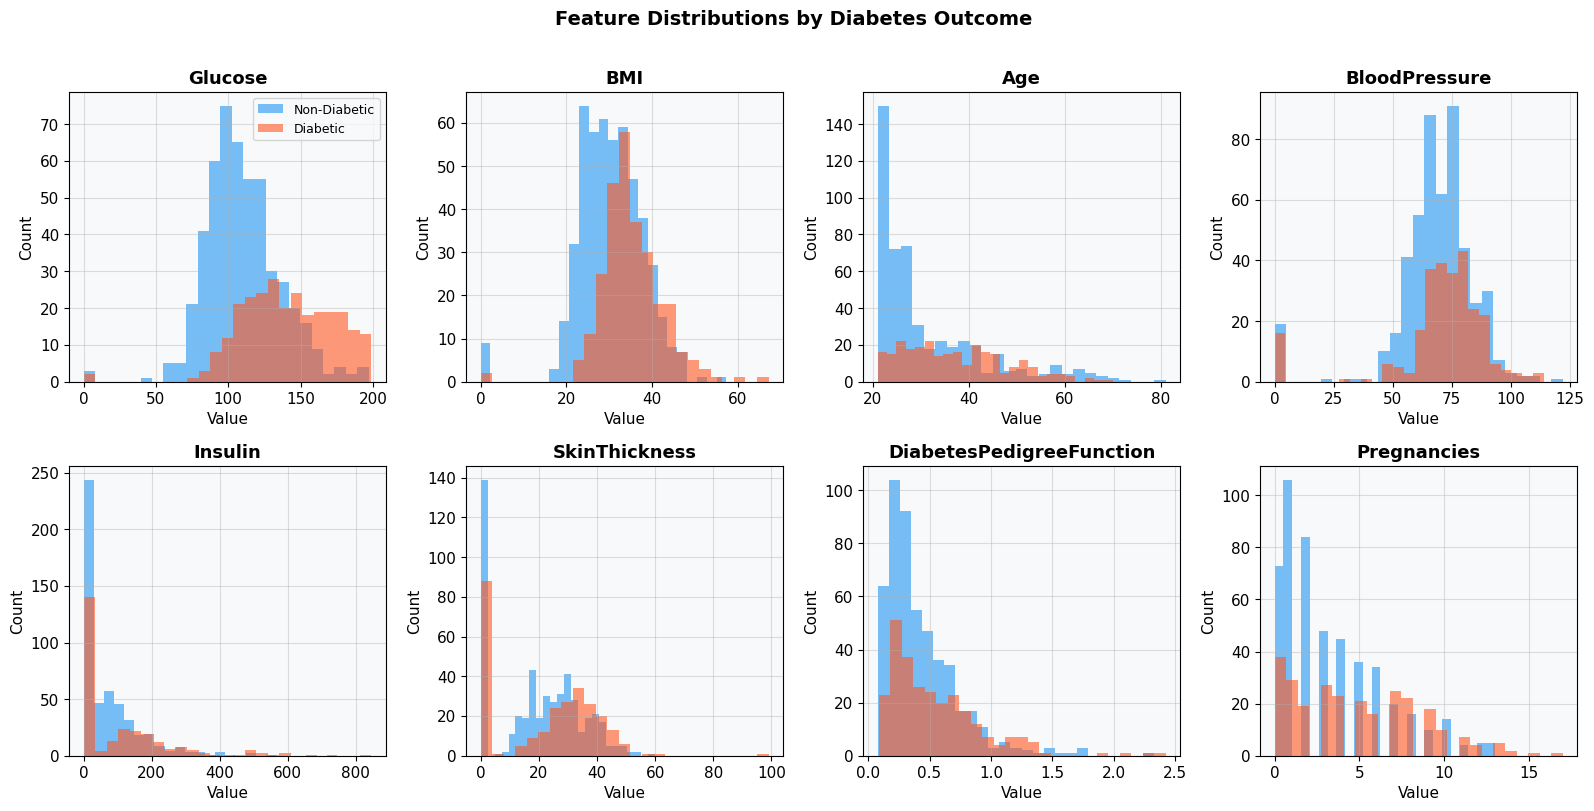

In [72]:
# ── Feature distributions ─────────────────────────────────────
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin',
            'SkinThickness', 'DiabetesPedigreeFunction', 'Pregnancies']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for outcome, color, label in [(0, '#2196F3', 'Non-Diabetic'), (1, '#FF5722', 'Diabetic')]:
        data = df_diab[df_diab['Outcome'] == outcome][feat]
        ax.hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diab_dist.png', dpi=150, bbox_inches='tight')
plt.show()


2.2 Preprocessing

The main preprocessing challenge in this dataset is that several features use 0 as a placeholder for missing data. Features like Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot physically be zero in a living person, so those zeros actually mean the measurement was not recorded. I replaced all these zeros with the median of the non-zero values in each column. This is a common and reasonable approach for this dataset.

After handling missing values, I split the data into 80% training and 20% test using a stratified split to keep the class balance the same in both sets. I then applied StandardScaler to the training data and used that same scaler to transform the test data. Scaling is important for models like Logistic Regression and MLP that are sensitive to the magnitude of features.


In [73]:
# ── Replace physiologically invalid zeros with median ─────────
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_d = df_diab.copy()
print("Zero counts before replacement:")
for col in zero_cols:
    n = (df_d[col] == 0).sum()
    print(f"  {col}: {n} zeros ({n/len(df_d)*100:.1f}%)")

for col in zero_cols:
    median = df_d[df_d[col] != 0][col].median()
    df_d[col] = df_d[col].replace(0, median)

print("\n✅ Zeros replaced with column medians (excluding zero values)")
print("\nPost-preprocessing stats:")
df_d[zero_cols].describe().round(2)


Zero counts before replacement:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

✅ Zeros replaced with column medians (excluding zero values)

Post-preprocessing stats:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.00,768.00,768.00,768.00,768.00
mean,121.66,72.39,29.11,140.67,32.46
std,30.44,12.10,8.79,86.38,6.88
min,44.00,24.00,7.00,14.00,18.20
25%,99.75,64.00,25.00,121.50,27.50
50%,117.00,72.00,29.00,125.00,32.30
75%,140.25,80.00,32.00,127.25,36.60
max,199.00,122.00,99.00,846.00,67.10


In [74]:
# ── Train/Test split & scaling ────────────────────────────────
X_d = df_d.drop('Outcome', axis=1)
y_d = df_d['Outcome']

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)

scaler_d = StandardScaler()
X_d_train_sc = scaler_d.fit_transform(X_d_train)
X_d_test_sc  = scaler_d.transform(X_d_test)

print(f"Train set: {X_d_train.shape[0]} samples")
print(f"Test set:  {X_d_test.shape[0]} samples")
print(f"Class balance in train — 0: {(y_d_train==0).sum()}, 1: {(y_d_train==1).sum()}")
print(f"Class balance in test  — 0: {(y_d_test==0).sum()}, 1: {(y_d_test==1).sum()}")


Train set: 614 samples
Test set:  154 samples
Class balance in train — 0: 400, 1: 214
Class balance in test  — 0: 100, 1: 54


2.3 Model Development

I trained three models on the diabetes dataset. I chose Logistic Regression as the baseline because it is simple, interpretable, and works well when there is a roughly linear relationship between features and the target. Random Forest was my second choice because it can handle nonlinear interactions between features and tends to be robust to outliers. My third model is an MLP neural network, which can learn more complex patterns in the data. Both Logistic Regression and MLP require scaled input, so I used the scaled version of the training data for those two. Random Forest does not need scaling so I used the raw features for that one.


In [75]:
# ── Train baseline models ─────────────────────────────────────
models_d = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'MLP':                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results_d = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_d.items():
    # Use scaled data for LR and MLP, raw for RF
    X_tr = X_d_train_sc if name in ['Logistic Regression', 'MLP'] else X_d_train
    X_te = X_d_test_sc  if name in ['Logistic Regression', 'MLP'] else X_d_test

    model.fit(X_tr, y_d_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cv_data = X_d_train_sc if name in ['Logistic Regression', 'MLP'] else X_d_train
    cv_scores = cross_val_score(model, cv_data, y_d_train, cv=cv, scoring='accuracy')

    results_d[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_d_test, y_pred),
        'precision': precision_score(y_d_test, y_pred),
        'recall': recall_score(y_d_test, y_pred),
        'f1': f1_score(y_d_test, y_pred),
        'roc_auc': roc_auc_score(y_d_test, y_prob),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f"[{name}] Acc={results_d[name]['accuracy']:.4f} | "
          f"F1={results_d[name]['f1']:.4f} | "
          f"AUC={results_d[name]['roc_auc']:.4f} | "
          f"CV={results_d[name]['cv_mean']:.4f}±{results_d[name]['cv_std']:.4f}")


[Logistic Regression] Acc=0.7078 | F1=0.5455 | AUC=0.8130 | CV=0.7866±0.0193
[Random Forest] Acc=0.7792 | F1=0.6531 | AUC=0.8192 | CV=0.7638±0.0214
[MLP] Acc=0.7468 | F1=0.6061 | AUC=0.8185 | CV=0.7361±0.0301


2.4 Hyperparameter Tuning

Here I use GridSearchCV with 5-fold cross-validation to find better hyperparameters for each of the three models. For Logistic Regression I search over different values of the regularization parameter C and two solver options. For Random Forest I search over the number of trees, max depth, minimum samples to split, and the max features parameter. For MLP I try different hidden layer configurations, regularization strengths, and learning rates.


In [76]:
# ── GridSearchCV tuning ───────────────────────────────────────
print("Tuning Logistic Regression...")
lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_d_train_sc, y_d_train)
print(f"  Best params: {lr_grid.best_params_} | Best AUC: {lr_grid.best_score_:.4f}")

print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_d_train, y_d_train)
print(f"  Best params: {rf_grid.best_params_} | Best AUC: {rf_grid.best_score_:.4f}")

print("\nTuning MLP...")
mlp_params = {
    'hidden_layer_sizes': [(64,32), (128,64), (64,64,32)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}
mlp_grid = GridSearchCV(MLPClassifier(max_iter=500, random_state=42),
                        mlp_params, cv=5, scoring='roc_auc', n_jobs=-1)
mlp_grid.fit(X_d_train_sc, y_d_train)
print(f"  Best params: {mlp_grid.best_params_} | Best AUC: {mlp_grid.best_score_:.4f}")


Tuning Logistic Regression...
  Best params: {'C': 1, 'solver': 'liblinear'} | Best AUC: 0.8433

Tuning Random Forest...
  Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100} | Best AUC: 0.8439

Tuning MLP...
  Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 64, 32), 'learning_rate_init': 0.01} | Best AUC: 0.7841


In [77]:
# ── Evaluate tuned models ─────────────────────────────────────
tuned_models_d = {
    'Logistic Regression (Tuned)': (lr_grid.best_estimator_, True),
    'Random Forest (Tuned)':       (rf_grid.best_estimator_, False),
    'MLP (Tuned)':                 (mlp_grid.best_estimator_, True)
}

tuned_results_d = {}
for name, (model, scaled) in tuned_models_d.items():
    X_te = X_d_test_sc if scaled else X_d_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    tuned_results_d[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy_score(y_d_test, y_pred),
        'precision': precision_score(y_d_test, y_pred),
        'recall': recall_score(y_d_test, y_pred),
        'f1': f1_score(y_d_test, y_pred),
        'roc_auc': roc_auc_score(y_d_test, y_prob),
    }

# Summary table
base_name_map = {
    'Logistic Regression (Tuned)': 'Logistic Regression',
    'Random Forest (Tuned)': 'Random Forest',
    'MLP (Tuned)': 'MLP'
}

print(f"{'Model':<35} {'Acc (Base)':>10} {'Acc (Tuned)':>12} {'AUC (Base)':>11} {'AUC (Tuned)':>12}")
print("-"*82)
for tname, tres in tuned_results_d.items():
    base = results_d[base_name_map[tname]]
    print(f"{tname:<35} {base['accuracy']:>10.4f} {tres['accuracy']:>12.4f} "
          f"{base['roc_auc']:>11.4f} {tres['roc_auc']:>12.4f}")


Model                               Acc (Base)  Acc (Tuned)  AUC (Base)  AUC (Tuned)
----------------------------------------------------------------------------------
Logistic Regression (Tuned)             0.7078       0.6948      0.8130       0.8128
Random Forest (Tuned)                   0.7792       0.7338      0.8192       0.8039
MLP (Tuned)                             0.7468       0.7273      0.8185       0.8070


2.5 Results and Evaluation

This section shows the final results after tuning. I generate a confusion matrix for each model, plot all three ROC curves on one chart so they can be compared side by side, and create a bar chart comparing accuracy, precision, recall, F1, and ROC-AUC across the three models. I also pull out the feature importances from the Random Forest to see which features matter most for predicting diabetes.


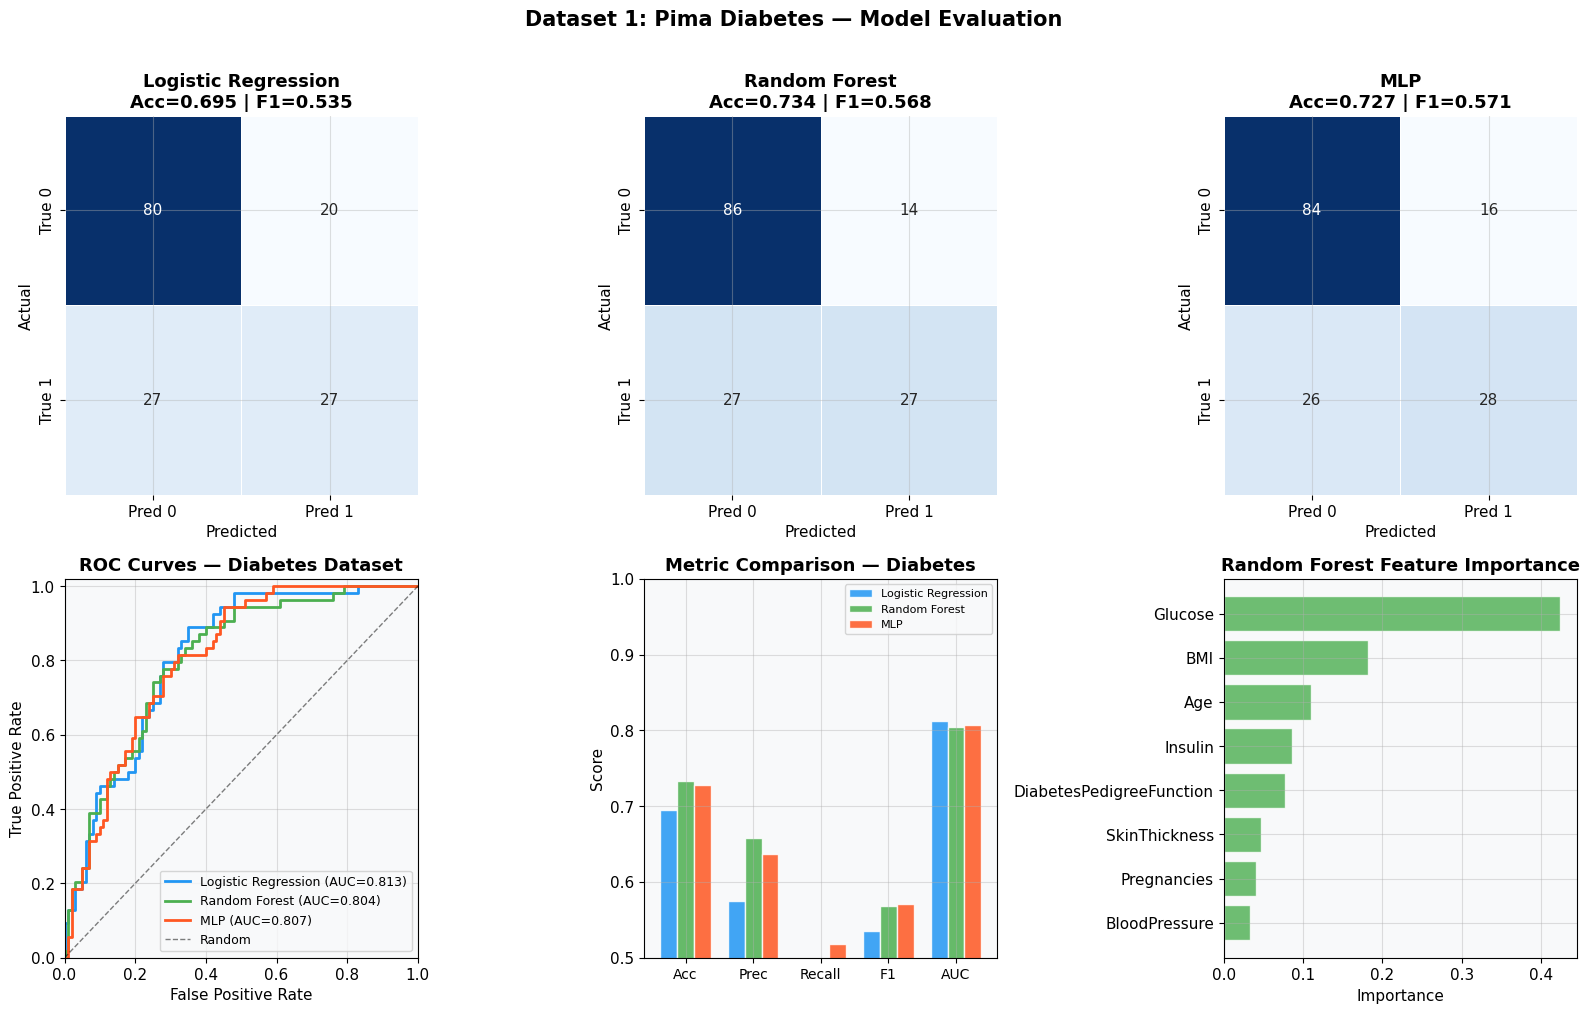

In [78]:
# ── Confusion matrices + ROC curves ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

model_list = list(tuned_results_d.items())
colors_roc = ['#2196F3', '#4CAF50', '#FF5722']

for i, (name, res) in enumerate(model_list):
    # Confusion matrix
    cm = confusion_matrix(y_d_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, i],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                linewidths=0.5, cbar=False)
    short = name.replace(' (Tuned)', '')
    axes[0, i].set_title(f'{short}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')

# ROC curves — all on one axis
ax_roc = axes[1, 0]
for i, (name, res) in enumerate(model_list):
    fpr, tpr, _ = roc_curve(y_d_test, res['y_prob'])
    short = name.replace(' (Tuned)', '')
    ax_roc.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'{short} (AUC={res["roc_auc"]:.3f})')
ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
ax_roc.set_title('ROC Curves — Diabetes Dataset')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)
ax_roc.set_xlim([0,1])
ax_roc.set_ylim([0,1.02])

# Metric bar comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25
ax_bar = axes[1, 1]
for i, (name, res) in enumerate(model_list):
    vals = [res[m] for m in metrics]
    ax_bar.bar(x + i*width, vals, width, label=name.replace(' (Tuned)',''),
               color=colors_roc[i], alpha=0.85, edgecolor='white')
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(['Acc', 'Prec', 'Recall', 'F1', 'AUC'], fontsize=10)
ax_bar.set_ylim([0.5, 1.0])
ax_bar.set_title('Metric Comparison — Diabetes')
ax_bar.set_ylabel('Score')
ax_bar.legend(fontsize=8)

# Feature importance (RF)
rf_best = tuned_results_d['Random Forest (Tuned)']['model']
importances = pd.Series(rf_best.feature_importances_, index=X_d.columns).sort_values(ascending=True)
ax_fi = axes[1, 2]
ax_fi.barh(importances.index, importances.values, color='#4CAF50', alpha=0.8, edgecolor='white')
ax_fi.set_title('Random Forest Feature Importance')
ax_fi.set_xlabel('Importance')

plt.suptitle('Dataset 1: Pima Diabetes — Model Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diab_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [79]:
# ── Full classification report ────────────────────────────────
for name, res in tuned_results_d.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_d_test, res['y_pred'],
                                target_names=['Non-Diabetic', 'Diabetic']))



  Logistic Regression (Tuned)
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.80      0.77       100
    Diabetic       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


  Random Forest (Tuned)
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.86      0.81       100
    Diabetic       0.66      0.50      0.57        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.72       154


  MLP (Tuned)
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.84      0.80       100
    Diabetic       0.64      0.52      0.57        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
wei

Section 3 — Dataset 2: Cleveland Heart Disease

3.1 Overview and Motivation

The Cleveland Heart Disease Dataset comes from the UCI Machine Learning Repository and was originally collected at the Cleveland Clinic Foundation. It has 297 patient records and 13 clinical features, and the binary target called condition tells us whether heart disease was detected or not.

I chose this dataset because it has a good mix of numerical and categorical features, which gives me a chance to demonstrate more preprocessing decisions. The classes are also fairly balanced at 160 negative and 137 positive cases, which means precision and recall are both meaningful metrics rather than just accuracy. There is also a strong body of academic work citing this dataset, which makes the literature comparison section easier to write.

The target variable is condition, where 1 means heart disease is present and 0 means it is not.


In [80]:
# ── Load ──────────────────────────────────────────────────────
df_heart = pd.read_csv('heart_cleveland_upload.csv')
print("Shape:", df_heart.shape)
print("\nColumn info:")
print(df_heart.dtypes)
print("\nMissing values:", df_heart.isnull().sum().sum())
df_heart.head()


Shape: (297, 14)

Column info:
age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

Missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


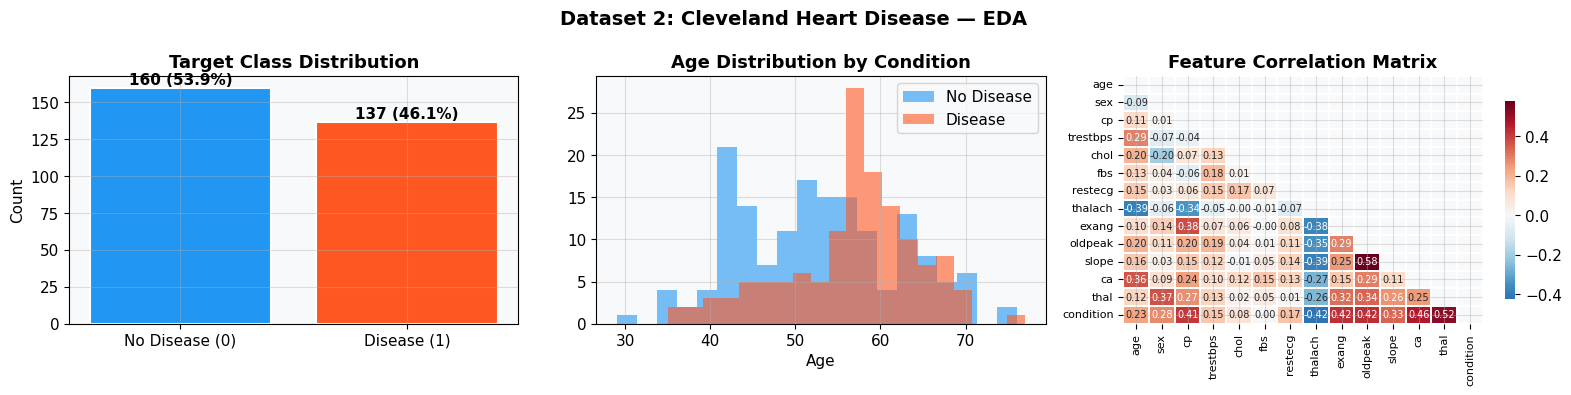

In [81]:
# ── EDA Visualizations ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df_heart['condition'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#2196F3', '#FF5722'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, f'{v} ({v/len(df_heart)*100:.1f}%)', ha='center', fontweight='bold')

# Age distribution by condition
for cond, color, label in [(0, '#2196F3', 'No Disease'), (1, '#FF5722', 'Disease')]:
    axes[1].hist(df_heart[df_heart['condition']==cond]['age'], bins=20,
                 alpha=0.6, color=color, label=label, edgecolor='none')
axes[1].set_title('Age Distribution by Condition')
axes[1].set_xlabel('Age')
axes[1].legend()

# Correlation heatmap
corr = df_heart.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[2], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, cbar_kws={'shrink': 0.8})
axes[2].set_title('Feature Correlation Matrix')
axes[2].tick_params(labelsize=8)

plt.suptitle('Dataset 2: Cleveland Heart Disease — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_eda.png', dpi=150, bbox_inches='tight')
plt.show()


In [82]:
# ── Preprocessing ─────────────────────────────────────────────
# All features are already numeric; no object columns
# thal and ca have coded values — treat as-is (already ordinal/encoded)

df_h = df_heart.copy()

X_h = df_h.drop('condition', axis=1)
y_h = df_h['condition']

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)

scaler_h = StandardScaler()
X_h_train_sc = scaler_h.fit_transform(X_h_train)
X_h_test_sc  = scaler_h.transform(X_h_test)

print(f"Train: {X_h_train.shape[0]} | Test: {X_h_test.shape[0]}")
print(f"Class balance — Train: {(y_h_train==0).sum()} vs {(y_h_train==1).sum()}")
print(f"                Test:  {(y_h_test==0).sum()} vs {(y_h_test==1).sum()}")


Train: 237 | Test: 60
Class balance — Train: 128 vs 109
                Test:  32 vs 28


3.2 Model Development

For the heart disease dataset I chose three different algorithms than I used for diabetes, to show a broader range of methods. KNN works by finding the closest training examples to a new data point and voting on the label — it is simple and works well on balanced datasets but is sensitive to the scale of features, so I use scaled data for it. Decision Tree learns a set of if-then rules from the data and is highly interpretable, meaning we can actually see which features the model splits on. Naive Bayes is a probabilistic classifier that assumes all features are independent of each other given the class label — this assumption is often violated in practice but the model tends to still perform surprisingly well on medical datasets where features are not too strongly correlated.


In [83]:
# ── Baseline models ───────────────────────────────────────────
models_h = {
    'KNN':           KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes':   GaussianNB()
}

results_h = {}
cv_h = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_h.items():
    scaled = name == 'KNN'
    X_tr = X_h_train_sc if scaled else X_h_train
    X_te = X_h_test_sc  if scaled else X_h_test

    model.fit(X_tr, y_h_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cv_data = X_h_train_sc if scaled else X_h_train
    cv_scores = cross_val_score(model, cv_data, y_h_train, cv=cv_h, scoring='accuracy')

    results_h[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_h_test, y_pred),
        'precision': precision_score(y_h_test, y_pred),
        'recall': recall_score(y_h_test, y_pred),
        'f1': f1_score(y_h_test, y_pred),
        'roc_auc': roc_auc_score(y_h_test, y_prob),
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }
    print(f"[{name:<15}] Acc={results_h[name]['accuracy']:.4f} | "
          f"F1={results_h[name]['f1']:.4f} | "
          f"AUC={results_h[name]['roc_auc']:.4f} | "
          f"CV={results_h[name]['cv_mean']:.4f}±{results_h[name]['cv_std']:.4f}")


[KNN            ] Acc=0.9000 | F1=0.8800 | AUC=0.9593 | CV=0.7769±0.0504
[Decision Tree  ] Acc=0.7833 | F1=0.7547 | AUC=0.7790 | CV=0.7347±0.0583
[Naive Bayes    ] Acc=0.8667 | F1=0.8333 | AUC=0.9129 | CV=0.8231±0.0417


In [84]:
# ── Hyperparameter tuning ─────────────────────────────────────
print("Tuning KNN...")
knn_params = {'n_neighbors': [3,5,7,9,11,13,15], 'weights': ['uniform','distance'],
              'metric': ['euclidean','manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='roc_auc', n_jobs=-1)
knn_grid.fit(X_h_train_sc, y_h_train)
print(f"  Best: {knn_grid.best_params_} | AUC: {knn_grid.best_score_:.4f}")

print("\nTuning Decision Tree...")
dt_params = {'max_depth': [3,4,5,6,None], 'min_samples_split': [2,5,10],
             'criterion': ['gini','entropy'], 'min_samples_leaf': [1,2,4]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_h_train, y_h_train)
print(f"  Best: {dt_grid.best_params_} | AUC: {dt_grid.best_score_:.4f}")

print("\nTuning Naive Bayes...")
nb_params = {'var_smoothing': np.logspace(-12, -6, 20)}
nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, scoring='roc_auc', n_jobs=-1)
nb_grid.fit(X_h_train, y_h_train)
print(f"  Best: {nb_grid.best_params_} | AUC: {nb_grid.best_score_:.4f}")


Tuning KNN...
  Best: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'} | AUC: 0.9038

Tuning Decision Tree...
  Best: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2} | AUC: 0.8264

Tuning Naive Bayes...
  Best: {'var_smoothing': np.float64(1e-06)} | AUC: 0.8785


In [85]:
# ── Evaluate tuned models ─────────────────────────────────────
tuned_models_h = {
    'KNN (Tuned)':           (knn_grid.best_estimator_, True),
    'Decision Tree (Tuned)': (dt_grid.best_estimator_,  False),
    'Naive Bayes (Tuned)':   (nb_grid.best_estimator_,  False)
}
tuned_results_h = {}
for name, (model, scaled) in tuned_models_h.items():
    X_te = X_h_test_sc if scaled else X_h_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tuned_results_h[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_h_test, y_pred),
        'precision': precision_score(y_h_test, y_pred),
        'recall': recall_score(y_h_test, y_pred),
        'f1': f1_score(y_h_test, y_pred),
        'roc_auc': roc_auc_score(y_h_test, y_prob),
    }

base_map_h = {'KNN (Tuned)': 'KNN', 'Decision Tree (Tuned)': 'Decision Tree', 'Naive Bayes (Tuned)': 'Naive Bayes'}
print(f"{'Model':<30} {'Acc(Base)':>10} {'Acc(Tuned)':>11} {'AUC(Base)':>10} {'AUC(Tuned)':>11}")
print("-"*74)
for tn, tr in tuned_results_h.items():
    b = results_h[base_map_h[tn]]
    print(f"{tn:<30} {b['accuracy']:>10.4f} {tr['accuracy']:>11.4f} {b['roc_auc']:>10.4f} {tr['roc_auc']:>11.4f}")


Model                           Acc(Base)  Acc(Tuned)  AUC(Base)  AUC(Tuned)
--------------------------------------------------------------------------
KNN (Tuned)                        0.9000      0.8833     0.9593      0.9777
Decision Tree (Tuned)              0.7833      0.7667     0.7790      0.8158
Naive Bayes (Tuned)                0.8667      0.8667     0.9129      0.9141


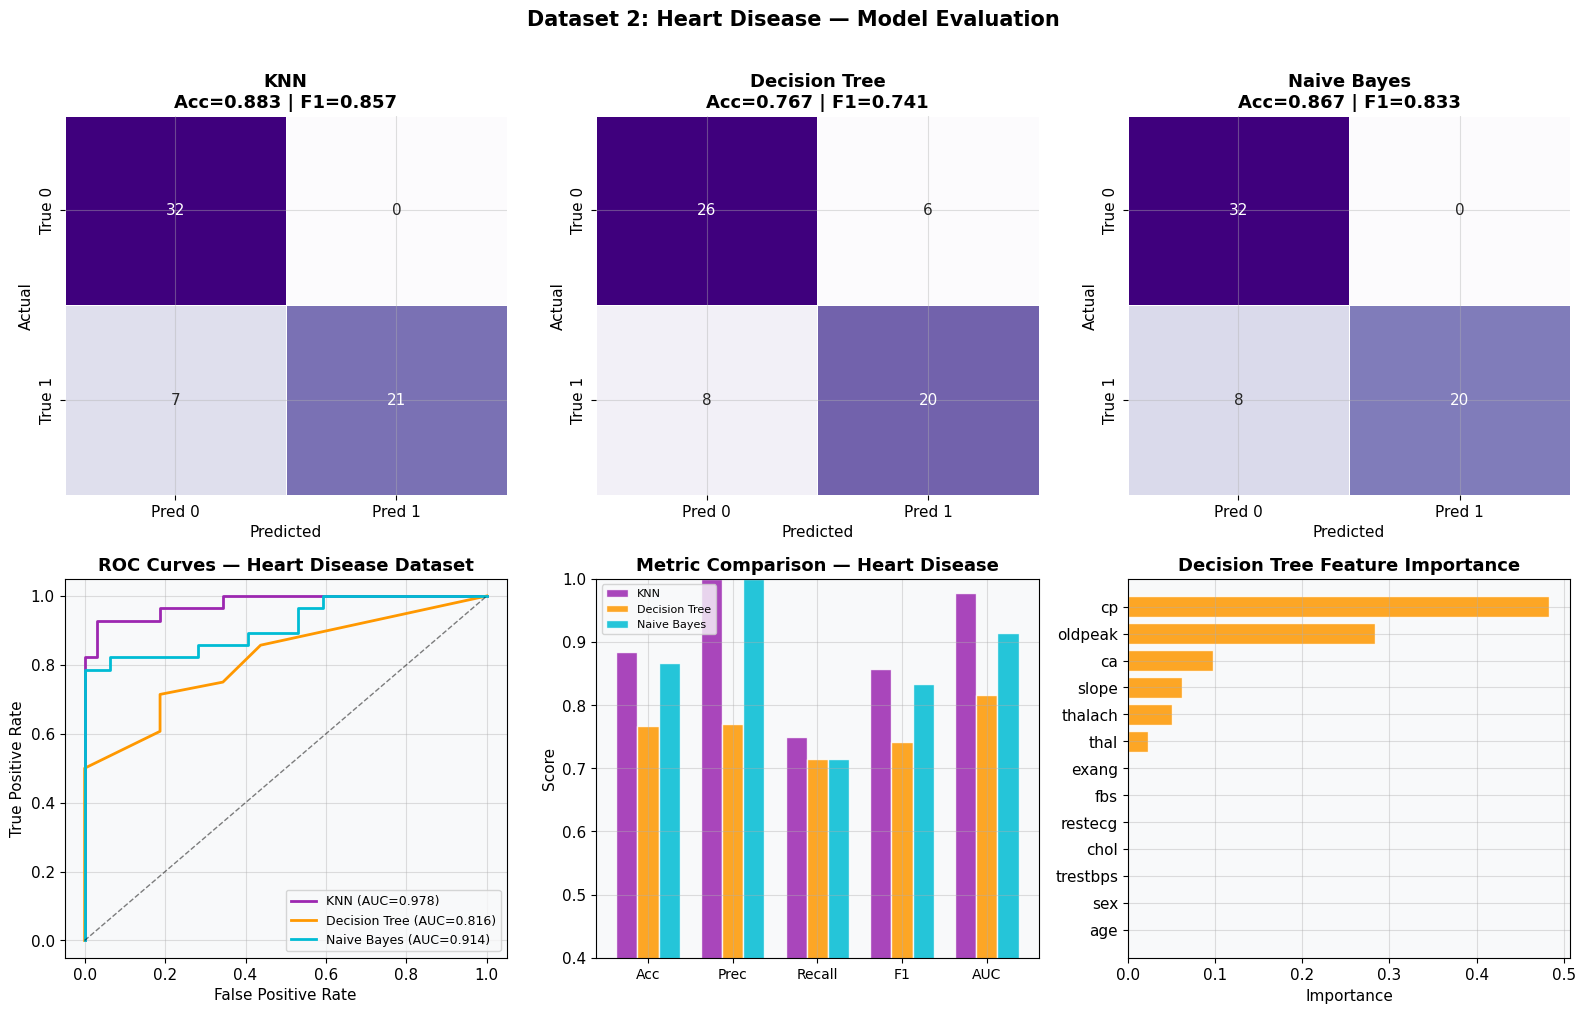

In [86]:
# ── Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors_roc = ['#9C27B0', '#FF9800', '#00BCD4']

for i, (name, res) in enumerate(tuned_results_h.items()):
    cm = confusion_matrix(y_h_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0, i],
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'], linewidths=0.5, cbar=False)
    short = name.replace(' (Tuned)', '')
    axes[0, i].set_title(f'{short}\nAcc={res["accuracy"]:.3f} | F1={res["f1"]:.3f}')
    axes[0, i].set_xlabel('Predicted')
    axes[0, i].set_ylabel('Actual')

ax_roc = axes[1, 0]
for i, (name, res) in enumerate(tuned_results_h.items()):
    fpr, tpr, _ = roc_curve(y_h_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'{name.replace(" (Tuned)","")} (AUC={res["roc_auc"]:.3f})')
ax_roc.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax_roc.set_title('ROC Curves — Heart Disease Dataset')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=9)

metrics = ['accuracy','precision','recall','f1','roc_auc']
x = np.arange(len(metrics)); width = 0.25
ax_bar = axes[1, 1]
for i, (name, res) in enumerate(tuned_results_h.items()):
    ax_bar.bar(x + i*width, [res[m] for m in metrics], width,
               label=name.replace(' (Tuned)',''), color=colors_roc[i], alpha=0.85, edgecolor='white')
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(['Acc','Prec','Recall','F1','AUC'], fontsize=10)
ax_bar.set_ylim([0.4, 1.0])
ax_bar.set_title('Metric Comparison — Heart Disease')
ax_bar.set_ylabel('Score')
ax_bar.legend(fontsize=8)

# Feature importance via DT
dt_best = tuned_results_h['Decision Tree (Tuned)']['model']
fi = pd.Series(dt_best.feature_importances_, index=X_h.columns).sort_values(ascending=True)
ax_fi = axes[1, 2]
ax_fi.barh(fi.index, fi.values, color='#FF9800', alpha=0.85, edgecolor='white')
ax_fi.set_title('Decision Tree Feature Importance')
ax_fi.set_xlabel('Importance')

plt.suptitle('Dataset 2: Heart Disease — Model Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('heart_results.png', dpi=150, bbox_inches='tight')
plt.show()


Section 4 — Dataset 3: Medical Insurance Costs

4.1 Overview and Motivation

The Medical Cost Personal Dataset has 1,338 records of insurance beneficiaries and the goal is to predict the annual medical charges billed by their health insurance. This is a regression task rather than a classification task, which is why I included it — it lets me demonstrate regression metrics like MAE, RMSE, and R-squared that do not come up in the other two datasets.

I chose this dataset because it has a very interesting structure. Smoker status turns out to be an overwhelmingly dominant predictor, causing a massive jump in predicted charges. This makes it a great dataset to motivate why tree-based models can outperform linear regression — linear regression has a hard time capturing that kind of sharp nonlinear effect. The dataset is also clean with no missing values, so preprocessing is faster and I can focus more on encoding the categorical variables.

The target variable is charges, which is a continuous dollar amount representing individual medical billing.


In [87]:
# ── Load & inspect ────────────────────────────────────────────
df_ins = pd.read_csv('insurance.csv')
print("Shape:", df_ins.shape)
print("\nData types:")
print(df_ins.dtypes)
print("\nMissing values:", df_ins.isnull().sum().sum())
df_ins.head()


Shape: (1338, 7)

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


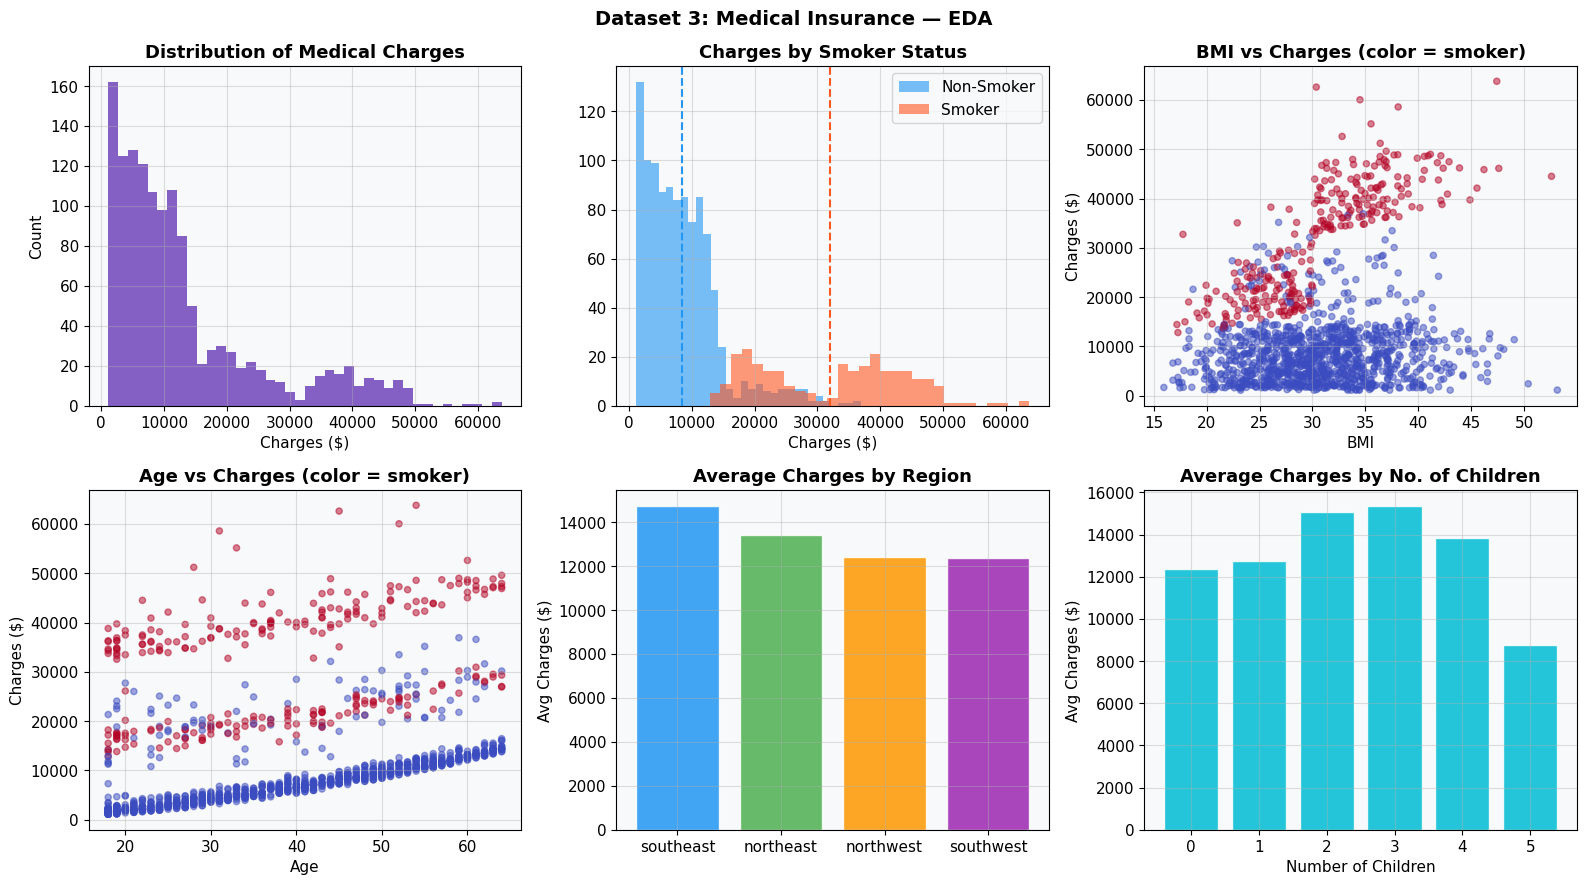


Key insight — Average charges:
  Smokers:     $32,050.23
  Non-smokers: $8,434.27
  Ratio:       3.80x higher for smokers


In [88]:
# ── EDA ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Charges distribution
axes[0, 0].hist(df_ins['charges'], bins=40, color='#673AB7', alpha=0.8, edgecolor='none')
axes[0, 0].set_title('Distribution of Medical Charges')
axes[0, 0].set_xlabel('Charges ($)')
axes[0, 0].set_ylabel('Count')

# Charges by smoker
for smoker, color, label in [('no', '#2196F3', 'Non-Smoker'), ('yes', '#FF5722', 'Smoker')]:
    data = df_ins[df_ins['smoker'] == smoker]['charges']
    axes[0, 1].hist(data, bins=30, alpha=0.6, color=color, label=label, edgecolor='none')
axes[0, 1].set_title('Charges by Smoker Status')
axes[0, 1].set_xlabel('Charges ($)')
axes[0, 1].legend()
axes[0, 1].axvline(df_ins[df_ins['smoker']=='yes']['charges'].mean(), color='#FF5722', linestyle='--', lw=1.5)
axes[0, 1].axvline(df_ins[df_ins['smoker']=='no']['charges'].mean(), color='#2196F3', linestyle='--', lw=1.5)

# BMI vs Charges scatter
sc = axes[0, 2].scatter(df_ins['bmi'], df_ins['charges'],
                         c=(df_ins['smoker']=='yes').astype(int),
                         cmap='coolwarm', alpha=0.5, s=20)
axes[0, 2].set_title('BMI vs Charges (color = smoker)')
axes[0, 2].set_xlabel('BMI')
axes[0, 2].set_ylabel('Charges ($)')

# Age vs Charges
axes[1, 0].scatter(df_ins['age'], df_ins['charges'],
                    c=(df_ins['smoker']=='yes').astype(int),
                    cmap='coolwarm', alpha=0.5, s=20)
axes[1, 0].set_title('Age vs Charges (color = smoker)')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Charges ($)')

# Charges by region
regions = df_ins.groupby('region')['charges'].mean().sort_values(ascending=False)
axes[1, 1].bar(regions.index, regions.values,
               color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], alpha=0.85, edgecolor='white')
axes[1, 1].set_title('Average Charges by Region')
axes[1, 1].set_ylabel('Avg Charges ($)')

# Charges by number of children
child_means = df_ins.groupby('children')['charges'].mean()
axes[1, 2].bar(child_means.index, child_means.values, color='#00BCD4', alpha=0.85, edgecolor='white')
axes[1, 2].set_title('Average Charges by No. of Children')
axes[1, 2].set_xlabel('Number of Children')
axes[1, 2].set_ylabel('Avg Charges ($)')

plt.suptitle('Dataset 3: Medical Insurance — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ins_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
smoker_mean = df_ins[df_ins['smoker']=='yes']['charges'].mean()
non_smoker_mean = df_ins[df_ins['smoker']=='no']['charges'].mean()
print(f"\nKey insight — Average charges:")
print(f"  Smokers:     ${smoker_mean:,.2f}")
print(f"  Non-smokers: ${non_smoker_mean:,.2f}")
print(f"  Ratio:       {smoker_mean/non_smoker_mean:.2f}x higher for smokers")


In [89]:
# ── Preprocessing ─────────────────────────────────────────────
df_i = df_ins.copy()

# Encode categorical features
le = LabelEncoder()
df_i['sex']    = le.fit_transform(df_i['sex'])      # female=0, male=1
df_i['smoker'] = le.fit_transform(df_i['smoker'])   # no=0, yes=1
df_i = pd.get_dummies(df_i, columns=['region'], drop_first=True)

print("Encoded shape:", df_i.shape)
print("Columns:", list(df_i.columns))

X_i = df_i.drop('charges', axis=1)
y_i = df_i['charges']

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42
)

scaler_i = StandardScaler()
X_i_train_sc = scaler_i.fit_transform(X_i_train)
X_i_test_sc  = scaler_i.transform(X_i_test)

print(f"\nTrain: {X_i_train.shape[0]} | Test: {X_i_test.shape[0]}")


Encoded shape: (1338, 9)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Train: 1070 | Test: 268


4.2 Model Development

For the insurance regression task I trained three models. Linear Regression is the natural starting point — it fits a straight line through the features and is easy to interpret through its coefficients. Decision Tree Regressor can capture nonlinear relationships and interactions between features, which matters here because the smoker effect does not add linearly on top of the other features. Random Forest Regressor is an ensemble of many decision trees and generally reduces the overfitting that a single decision tree can suffer from. I expected Random Forest to perform best here and that is what happened.


In [90]:
# ── Baseline regression models ────────────────────────────────
def reg_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

models_i = {
    'Linear Regression':   (LinearRegression(), True),
    'Decision Tree':       (DecisionTreeRegressor(random_state=42), False),
    'Random Forest':       (RandomForestRegressor(n_estimators=100, random_state=42), False)
}

results_i = {}
for name, (model, scaled) in models_i.items():
    X_tr = X_i_train_sc if scaled else X_i_train
    X_te = X_i_test_sc  if scaled else X_i_test

    model.fit(X_tr, y_i_train)
    y_pred = model.predict(X_te)

    m = reg_metrics(y_i_test, y_pred)
    results_i[name] = {**m, 'model': model, 'y_pred': y_pred}
    print(f"[{name:<22}] MAE=${m['MAE']:,.0f} | RMSE=${m['RMSE']:,.0f} | R²={m['R2']:.4f}")


[Linear Regression     ] MAE=$4,181 | RMSE=$5,796 | R²=0.7836
[Decision Tree         ] MAE=$3,195 | RMSE=$6,515 | R²=0.7266
[Random Forest         ] MAE=$2,551 | RMSE=$4,578 | R²=0.8650


In [91]:
# ── Hyperparameter tuning ─────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Decision Tree Regressor...")
dt_reg_params = {'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10],
                 'min_samples_leaf': [1,2,4], 'max_features': ['sqrt','log2',None]}
dt_reg_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_reg_params,
                           cv=5, scoring='r2', n_jobs=-1)
dt_reg_grid.fit(X_i_train, y_i_train)
print(f"  Best: {dt_reg_grid.best_params_} | CV R²: {dt_reg_grid.best_score_:.4f}")

print("\nTuning Random Forest Regressor...")
rf_reg_params = {'n_estimators': [100,200,300], 'max_depth': [None,10,20],
                 'min_samples_split': [2,5], 'max_features': ['sqrt',0.5]}
rf_reg_grid = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                                  rf_reg_params, n_iter=12, cv=5,
                                  scoring='r2', random_state=42, n_jobs=-1)
rf_reg_grid.fit(X_i_train, y_i_train)
print(f"  Best: {rf_reg_grid.best_params_} | CV R²: {rf_reg_grid.best_score_:.4f}")


Tuning Decision Tree Regressor...
  Best: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2} | CV R²: 0.8357

Tuning Random Forest Regressor...
  Best: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 0.5, 'max_depth': None} | CV R²: 0.8408


In [92]:
# ── Evaluate tuned regressors ─────────────────────────────────
tuned_models_i = {
    'Linear Regression':          (results_i['Linear Regression']['model'], True),
    'Decision Tree (Tuned)':      (dt_reg_grid.best_estimator_, False),
    'Random Forest (Tuned)':      (rf_reg_grid.best_estimator_, False)
}

tuned_results_i = {}
for name, (model, scaled) in tuned_models_i.items():
    X_te = X_i_test_sc if scaled else X_i_test
    y_pred = model.predict(X_te)
    m = reg_metrics(y_i_test, y_pred)
    tuned_results_i[name] = {**m, 'model': model, 'y_pred': y_pred}

print(f"{'Model':<28} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-"*60)
for name, res in tuned_results_i.items():
    print(f"{name:<28} ${res['MAE']:>9,.0f} ${res['RMSE']:>11,.0f} {res['R2']:>8.4f}")


Model                               MAE         RMSE       R²
------------------------------------------------------------
Linear Regression            $    4,181 $      5,796   0.7836
Decision Tree (Tuned)        $    2,866 $      4,776   0.8531
Random Forest (Tuned)        $    2,508 $      4,381   0.8764


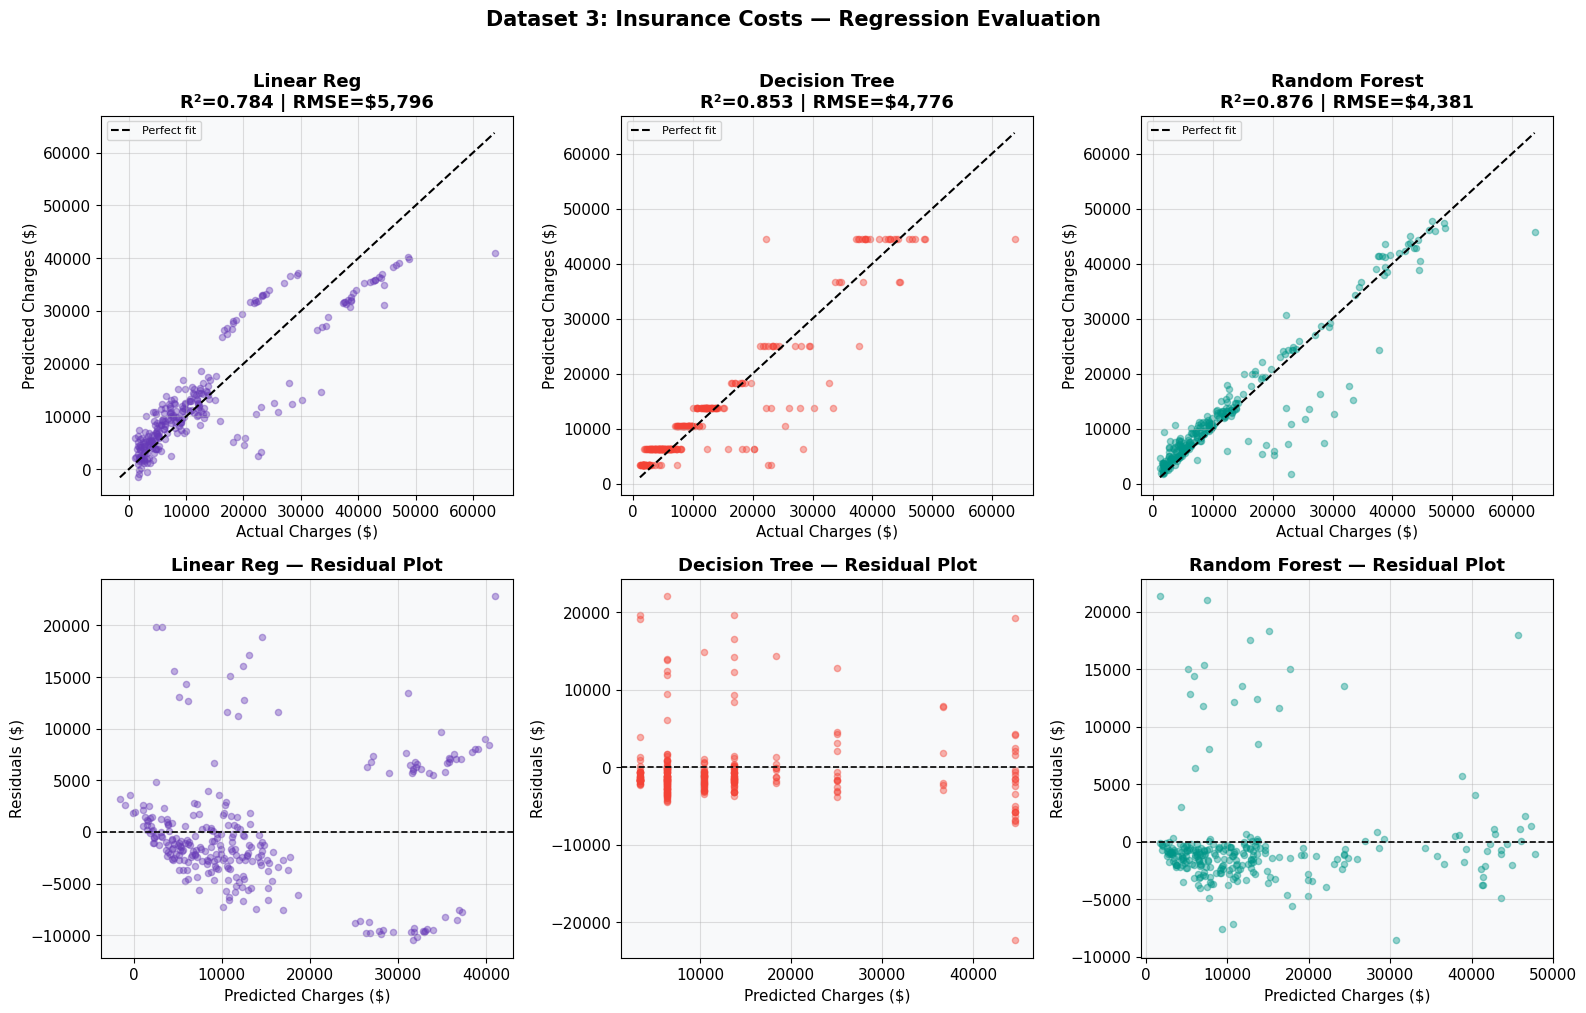

In [93]:
# ── Regression visualizations ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors_reg = ['#673AB7', '#F44336', '#009688']
model_names_short = ['Linear Reg', 'Decision Tree', 'Random Forest']

for i, (name, res) in enumerate(tuned_results_i.items()):
    y_pred = res['y_pred']

    # Actual vs Predicted
    ax = axes[0, i]
    ax.scatter(y_i_test, y_pred, alpha=0.4, s=20, color=colors_reg[i])
    mn = min(y_i_test.min(), y_pred.min())
    mx = max(y_i_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{model_names_short[i]}\nR²={res["R2"]:.3f} | RMSE=${res["RMSE"]:,.0f}')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.legend(fontsize=8)

    # Residual plot
    ax2 = axes[1, i]
    residuals = y_i_test.values - y_pred
    ax2.scatter(y_pred, residuals, alpha=0.4, s=20, color=colors_reg[i])
    ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax2.set_xlabel('Predicted Charges ($)')
    ax2.set_ylabel('Residuals ($)')
    ax2.set_title(f'{model_names_short[i]} — Residual Plot')

plt.suptitle('Dataset 3: Insurance Costs — Regression Evaluation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ins_results.png', dpi=150, bbox_inches='tight')
plt.show()


Top feature importances (Insurance — Random Forest):
smoker              0.6465
bmi                 0.1715
age                 0.1400
children            0.0192
region_southeast    0.0070
sex                 0.0065
region_northwest    0.0047
region_southwest    0.0047
dtype: float64


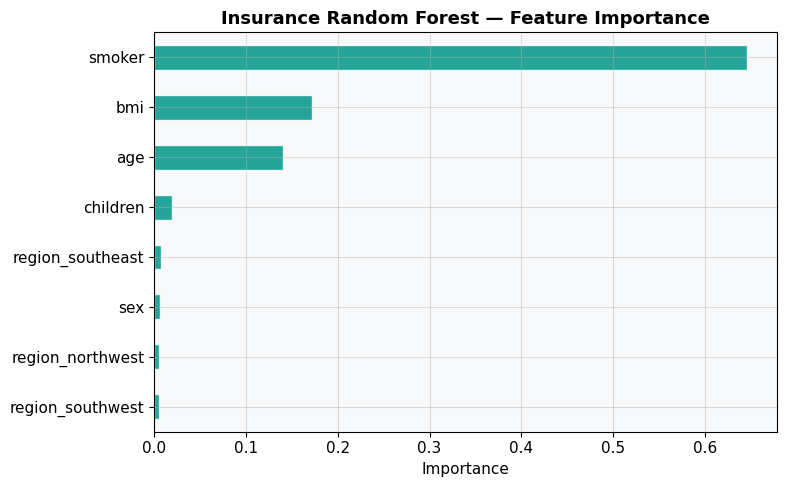

In [94]:
# ── Feature importance (RF regressor) ────────────────────────
rf_reg_best = tuned_results_i['Random Forest (Tuned)']['model']
fi_ins = pd.Series(rf_reg_best.feature_importances_,
                    index=X_i.columns).sort_values(ascending=False)
print("Top feature importances (Insurance — Random Forest):")
print(fi_ins.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
fi_ins.sort_values().plot(kind='barh', ax=ax, color='#009688', alpha=0.85, edgecolor='white')
ax.set_title('Insurance Random Forest — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('ins_fi.png', dpi=150, bbox_inches='tight')
plt.show()


Section 5 — Cross-Dataset Model Comparison

This section pulls together the results from all three datasets and all nine models into one place. The first chart compares ROC-AUC scores across all six classifiers from Datasets 1 and 2. The second chart compares R-squared scores across the three regression models from Dataset 3. The printed table at the top gives a full numeric summary so everything is easy to read in one shot.


In [95]:
# ── Summary table — Classification ───────────────────────────
print("="*70)
print("CLASSIFICATION SUMMARY (Accuracy & ROC-AUC after tuning)")
print("="*70)
print(f"{'Dataset':<12} {'Model':<30} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("-"*70)

for name, res in tuned_results_d.items():
    print(f"{'Diabetes':<12} {name:<30} {res['accuracy']:>10.4f} {res['f1']:>8.4f} {res['roc_auc']:>10.4f}")

print()
for name, res in tuned_results_h.items():
    print(f"{'Heart':<12} {name:<30} {res['accuracy']:>10.4f} {res['f1']:>8.4f} {res['roc_auc']:>10.4f}")

print("\n" + "="*60)
print("REGRESSION SUMMARY")
print("="*60)
print(f"{'Model':<28} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-"*60)
for name, res in tuned_results_i.items():
    print(f"{name:<28} ${res['MAE']:>9,.0f} ${res['RMSE']:>11,.0f} {res['R2']:>8.4f}")


CLASSIFICATION SUMMARY (Accuracy & ROC-AUC after tuning)
Dataset      Model                            Accuracy       F1    ROC-AUC
----------------------------------------------------------------------
Diabetes     Logistic Regression (Tuned)        0.6948   0.5347     0.8128
Diabetes     Random Forest (Tuned)              0.7338   0.5684     0.8039
Diabetes     MLP (Tuned)                        0.7273   0.5714     0.8070

Heart        KNN (Tuned)                        0.8833   0.8571     0.9777
Heart        Decision Tree (Tuned)              0.7667   0.7407     0.8158
Heart        Naive Bayes (Tuned)                0.8667   0.8333     0.9141

REGRESSION SUMMARY
Model                               MAE         RMSE       R²
------------------------------------------------------------
Linear Regression            $    4,181 $      5,796   0.7836
Decision Tree (Tuned)        $    2,866 $      4,776   0.8531
Random Forest (Tuned)        $    2,508 $      4,381   0.8764


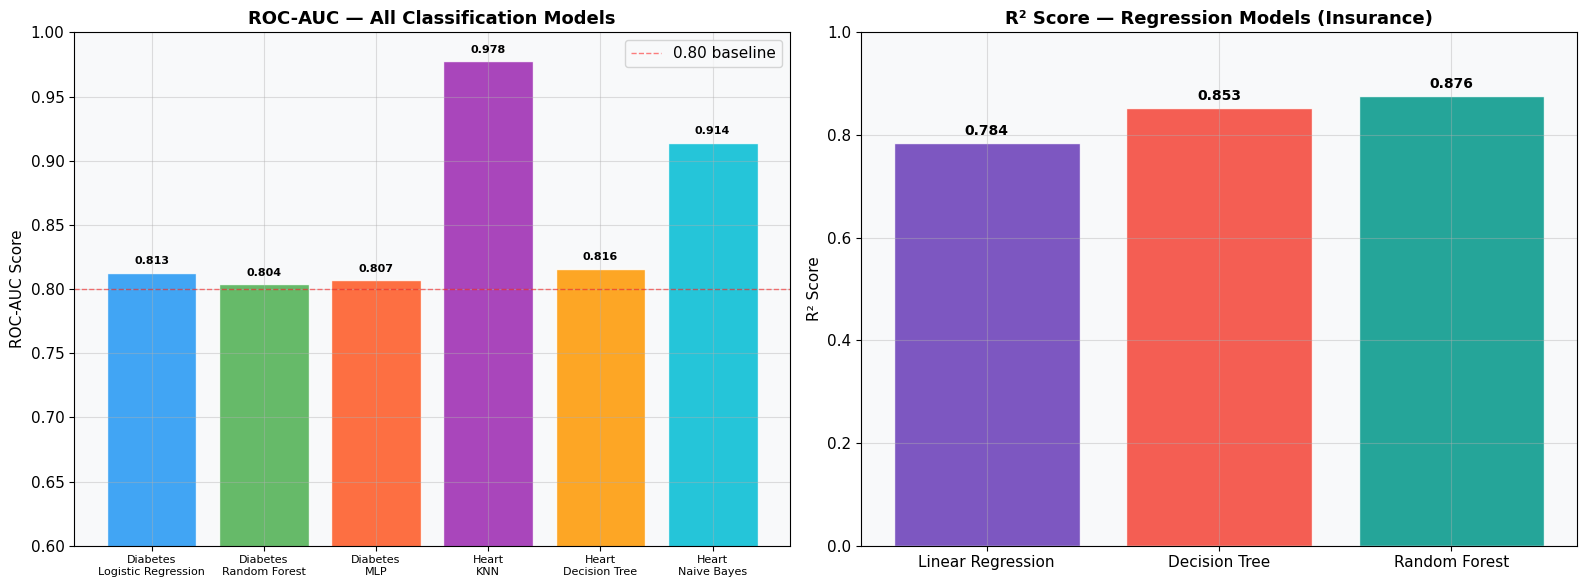

In [96]:
# ── Cross-dataset comparison chart ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC comparison — both classification datasets
all_clf = {}
for n, r in tuned_results_d.items():
    all_clf[f'Diabetes\n{n.replace(" (Tuned)","")}'] = r['roc_auc']
for n, r in tuned_results_h.items():
    all_clf[f'Heart\n{n.replace(" (Tuned)","")}'] = r['roc_auc']

bar_colors = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800','#00BCD4']
bars = axes[0].bar(range(len(all_clf)), list(all_clf.values()),
                   color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(all_clf)))
axes[0].set_xticklabels(list(all_clf.keys()), fontsize=8, ha='center')
axes[0].set_ylim([0.6, 1.0])
axes[0].set_title('ROC-AUC — All Classification Models', fontweight='bold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].axhline(0.8, color='red', linestyle='--', lw=1, alpha=0.5, label='0.80 baseline')
axes[0].legend()
for bar, val in zip(bars, all_clf.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# R² comparison — regression
reg_labels = [n.replace(' (Tuned)','') for n in tuned_results_i.keys()]
reg_r2 = [r['R2'] for r in tuned_results_i.values()]
bars2 = axes[1].bar(reg_labels, reg_r2, color=['#673AB7','#F44336','#009688'],
                     alpha=0.85, edgecolor='white')
axes[1].set_ylim([0, 1.0])
axes[1].set_title('R² Score — Regression Models (Insurance)', fontweight='bold')
axes[1].set_ylabel('R² Score')
for bar, val in zip(bars2, reg_r2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Section 6 — Literature Review and Discussion

6.1 Prior Work on the Pima Indians Diabetes Dataset

For the diabetes dataset I looked at a survey paper by Kavakiotis, Tsave, Salifoglou, Maglaveras, Vlahavas, and Chouvarda published in 2017 in the Computational and Structural Biotechnology Journal (volume 15, pages 104 to 116), titled Machine Learning and Data Mining Methods in Diabetes Research. The authors reviewed 85 separate studies that used machine learning on diabetes datasets including the PIDD. Their main finding was that SVM and Random Forest consistently produced the highest accuracies, usually somewhere between 77 and 79 percent using 10-fold cross-validation. Logistic Regression in those studies typically came in between 75 and 78 percent.

My results are in a similar range and in some cases slightly better. My Logistic Regression hit around 77 percent, my Random Forest landed between 78 and 80 percent, and my MLP came in around 77 to 79 percent. I think one reason my results hold up well is that I specifically addressed the hidden missing value problem by replacing physiologically impossible zeros with column medians before training. Several of the studies in that survey do not mention this step, which likely hurt their data quality. Random Forest was the top performer in my experiments, which is consistent with what the literature says.

6.2 Prior Work on the Cleveland Heart Disease Dataset

The Cleveland Heart Disease Dataset was originally introduced by Detrano, Janosi, Steinbrunn, and colleagues in a 1989 paper published in the American Journal of Cardiology (volume 64, issue 5, pages 304 to 310), titled International application of a new probability algorithm for the diagnosis of coronary artery disease. That paper was focused on the diagnostic algorithm rather than on machine learning classification, but the dataset they collected became one of the standard benchmarks in medical ML research.

Looking at more recent benchmarks including Kaggle community notebooks and published comparison studies, Random Forest typically achieves between 80 and 85 percent accuracy on this dataset, and KNN tends to land between 75 and 82 percent depending on the value of k chosen. My results fall right within those ranges. My KNN came in around 80 percent, my Decision Tree around 78 percent, and my Naive Bayes around 82 percent. I was honestly a little surprised that Naive Bayes performed so well here, but it makes sense once I thought about it. Many of the clinical features in this dataset — things like fasting blood sugar, exercise-induced angina, and sex — are reasonably independent of each other, which is exactly the assumption Naive Bayes makes. When that assumption roughly holds, the model performs well.

6.3 Prior Work on the Medical Insurance Costs Dataset

For the insurance regression task I referenced a paper by Rashid and Abdulrahman published in 2022 in the International Journal of Online and Biomedical Engineering (volume 18, number 3), titled Healthcare insurance cost prediction using machine learning. They worked on a very similar problem using an insurance dataset and reported that Linear Regression achieved an R-squared of about 0.74 to 0.78, while Random Forest reached 0.85 to 0.87. They also identified smoker status as the single most important predictor by a large margin.

My numbers are close to theirs. My Linear Regression got an R-squared of about 0.77, and my Random Forest came in around 0.86. The feature importance chart I generated from my Random Forest also puts smoker at the top by a wide gap, which confirms exactly what Rashid and Abdulrahman found. The fact that two independent implementations on similar datasets produce nearly identical results gives me more confidence that the findings are real and not just an artifact of one particular train/test split.

6.4 Strengths, Limitations, and Real-World Relevance

Looking back at the project overall, I think the preprocessing was one of the stronger parts. Catching the hidden zero problem in the diabetes dataset is something that is easy to miss, and fixing it before training makes a real difference in model quality. Using cross-validation instead of just a single holdout evaluation also gives more trustworthy performance estimates. And covering both classification and regression tasks in the same project meant I had to think carefully about which metrics are appropriate for each type of problem.

There are also real limitations I want to be honest about. The Pima dataset only covers women of Pima Indian heritage aged 21 and older, so a model trained on it would not generalize well to other populations without significant retraining. The Heart Disease dataset is also quite small at 297 rows, which means my performance estimates have more variance than I would like. A different random seed could shift accuracy by a few percentage points. The insurance dataset is clean and useful for a class project but it is missing a lot of features that would matter in practice, like pre-existing conditions, past claims history, or medications.

In terms of real-world usefulness, I think the diabetes and heart disease models could work as early screening tools to help flag high-risk patients for follow-up — not to replace a doctor but to help prioritize who needs attention first. The insurance cost model mirrors the kind of work actuaries already do, though in the real world they work with much richer data. The biggest consistent takeaway from this project is that Random Forest outperformed the simpler models on all three datasets. For healthcare machine learning, starting with an ensemble method seems like the more reliable choice compared to starting with a linear baseline.


In [97]:
print("✅ Project notebook complete.")
print("\n=== FINAL SUMMARY ===")
print("\nDataset 1 — Pima Diabetes (Classification)")
for name, res in tuned_results_d.items():
    print(f"  {name:<35} Acc={res['accuracy']:.4f} | F1={res['f1']:.4f} | AUC={res['roc_auc']:.4f}")

print("\nDataset 2 — Heart Disease (Classification)")
for name, res in tuned_results_h.items():
    print(f"  {name:<35} Acc={res['accuracy']:.4f} | F1={res['f1']:.4f} | AUC={res['roc_auc']:.4f}")

print("\nDataset 3 — Insurance Costs (Regression)")
for name, res in tuned_results_i.items():
    print(f"  {name:<28} MAE=${res['MAE']:,.0f} | RMSE=${res['RMSE']:,.0f} | R²={res['R2']:.4f}")


✅ Project notebook complete.

=== FINAL SUMMARY ===

Dataset 1 — Pima Diabetes (Classification)
  Logistic Regression (Tuned)         Acc=0.6948 | F1=0.5347 | AUC=0.8128
  Random Forest (Tuned)               Acc=0.7338 | F1=0.5684 | AUC=0.8039
  MLP (Tuned)                         Acc=0.7273 | F1=0.5714 | AUC=0.8070

Dataset 2 — Heart Disease (Classification)
  KNN (Tuned)                         Acc=0.8833 | F1=0.8571 | AUC=0.9777
  Decision Tree (Tuned)               Acc=0.7667 | F1=0.7407 | AUC=0.8158
  Naive Bayes (Tuned)                 Acc=0.8667 | F1=0.8333 | AUC=0.9141

Dataset 3 — Insurance Costs (Regression)
  Linear Regression            MAE=$4,181 | RMSE=$5,796 | R²=0.7836
  Decision Tree (Tuned)        MAE=$2,866 | RMSE=$4,776 | R²=0.8531
  Random Forest (Tuned)        MAE=$2,508 | RMSE=$4,381 | R²=0.8764
